In [144]:
import pandas as pd
import torch
from transformers import AutoModel, AutoTokenizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
import joblib
import os

In [145]:
print(torch.cuda.is_available())
print(torch.version.cuda)

False
None


In [146]:
df = pd.read_csv('datasets/msl_clean.csv')
df = df[['Chromophore', 'Solvent', 'Quantum yield']]
df.head()



,Chromophore,Solvent,Quantum yield
0,O=C([O-])c1ccccc1-c1c2ccc(=O)cc-2oc2cc([O-])ccc12,O,0.950
1,O=C([O-])c1ccccc1C1=c2cc3c4c(c2Oc2c1cc1c5c2CCC...,CO,1.000
2,O=C([O-])c1ccccc1-c1c2cc(Br)c(=O)c(Br)c-2oc2c(...,O,0.200
3,O=C([O-])c1ccccc1-c1c2cc(I)c(=O)c(I)c-2oc2c(I)...,O,0.020
4,O=C([O-])c1c(Cl)c(Cl)c(Cl)c(Cl)c1-c1c2cc(I)c(=...,O,0.018


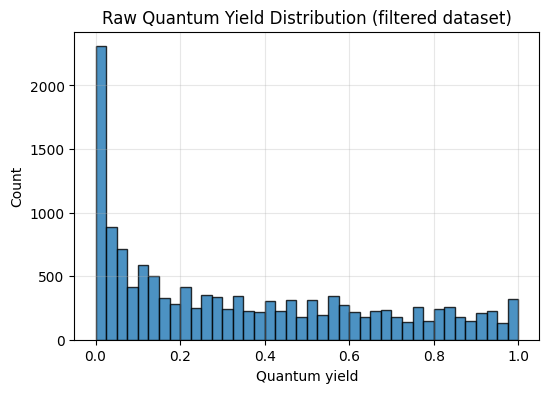

In [147]:
plt.figure(figsize=(6,4))
plt.hist(df["Quantum yield"], bins=40, alpha=0.8, edgecolor="black")
plt.xlabel("Quantum yield")
plt.ylabel("Count")
plt.title("Raw Quantum Yield Distribution (filtered dataset)")
plt.grid(True, alpha=0.3)
plt.show()


In [148]:
from rdkit import Chem
from rdkit.Chem import Descriptors
from rdkit.Chem.Draw import MolToImage

mol_list = []

for smile in df['Chromophore']:
    mol = Chem.MolFromSmiles(smile)
    print(type(mol))
    mol_list.append(mol)
    print(f"Num of atoms: {mol.GetNumAtoms()}")
    print(f"Mol weight: {Descriptors.MolWt(mol)}")
    print('------------------------------------------------')

<class 'rdkit.Chem.rdchem.Mol'>
Num of atoms: 25
Mol weight: 330.295
------------------------------------------------
<class 'rdkit.Chem.rdchem.Mol'>
Num of atoms: 37
Mol weight: 490.6030000000005
------------------------------------------------
<class 'rdkit.Chem.rdchem.Mol'>
Num of atoms: 29
Mol weight: 645.879
------------------------------------------------
<class 'rdkit.Chem.rdchem.Mol'>
Num of atoms: 29
Mol weight: 833.879
------------------------------------------------
<class 'rdkit.Chem.rdchem.Mol'>
Num of atoms: 33
Mol weight: 971.659
------------------------------------------------
<class 'rdkit.Chem.rdchem.Mol'>
Num of atoms: 29
Mol weight: 645.879
------------------------------------------------
<class 'rdkit.Chem.rdchem.Mol'>
Num of atoms: 29
Mol weight: 833.879
------------------------------------------------
<class 'rdkit.Chem.rdchem.Mol'>
Num of atoms: 33
Mol weight: 971.659
------------------------------------------------
<class 'rdkit.Chem.rdchem.Mol'>
Num of atoms: 

In [149]:
imgs_2d = []

for mol in mol_list:
    img = MolToImage(mol)
    imgs_2d.append(img)
    print(type(img))


<class 'PIL.PngImagePlugin.PngImageFile'>
<class 'PIL.PngImagePlugin.PngImageFile'>
<class 'PIL.PngImagePlugin.PngImageFile'>
<class 'PIL.PngImagePlugin.PngImageFile'>
<class 'PIL.PngImagePlugin.PngImageFile'>
<class 'PIL.PngImagePlugin.PngImageFile'>
<class 'PIL.PngImagePlugin.PngImageFile'>
<class 'PIL.PngImagePlugin.PngImageFile'>
<class 'PIL.PngImagePlugin.PngImageFile'>
<class 'PIL.PngImagePlugin.PngImageFile'>
<class 'PIL.PngImagePlugin.PngImageFile'>
<class 'PIL.PngImagePlugin.PngImageFile'>
<class 'PIL.PngImagePlugin.PngImageFile'>
<class 'PIL.PngImagePlugin.PngImageFile'>
<class 'PIL.PngImagePlugin.PngImageFile'>
<class 'PIL.PngImagePlugin.PngImageFile'>
<class 'PIL.PngImagePlugin.PngImageFile'>
<class 'PIL.PngImagePlugin.PngImageFile'>
<class 'PIL.PngImagePlugin.PngImageFile'>
<class 'PIL.PngImagePlugin.PngImageFile'>
<class 'PIL.PngImagePlugin.PngImageFile'>
<class 'PIL.PngImagePlugin.PngImageFile'>
<class 'PIL.PngImagePlugin.PngImageFile'>
<class 'PIL.PngImagePlugin.PngImag

In [150]:
model = AutoModel.from_pretrained("ibm/MoLFormer-XL-both-10pct", deterministic_eval=True, trust_remote_code=True)
tokenizer = AutoTokenizer.from_pretrained("ibm/MoLFormer-XL-both-10pct", trust_remote_code=True)


In [151]:
import torch

CACHE_FILE = "embedding caches/clean_embed.pt"

def load_cache():
    if os.path.exists(CACHE_FILE):
        return torch.load(CACHE_FILE)
    else:
        return {}  # empty cache

def save_cache(cache):
    torch.save(cache, CACHE_FILE)

In [152]:
def get_embeddings(smiles_list, batch_size=32, max_length=202):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    cache = load_cache()
    all_embeddings = []


    to_compute = [s for s in smiles_list if s not in cache]

    if len(to_compute) > 0:
        print(f"Computing {len(to_compute)} new embeddings on {device}...")


        model.to(device)
        model.eval()

        with torch.no_grad():
            for i in range(0, len(to_compute), batch_size):
                batch = to_compute[i:i+batch_size]

                inputs = tokenizer(
                    batch, padding=True, truncation=True,
                    max_length=max_length, return_tensors="pt"
                ).to(device)


                outputs = model(**inputs)
                embeddings = outputs.pooler_output 


                for s, emb in zip(batch, embeddings):
                    cache[s] = emb.cpu()


        save_cache(cache)

    else:
        print("All embeddings already in cache.")


    ordered = [cache[s] for s in smiles_list]
    return torch.stack(ordered)


In [153]:
chrom_emb = get_embeddings(df["Chromophore"].tolist())
print("Chromophore embeddings shape:", chrom_emb.shape)

solv_emb = get_embeddings(df["Solvent"].tolist())
print("Solvent embeddings shape:", solv_emb.shape)

combined_emb = torch.cat([chrom_emb, solv_emb], dim=1)
print("Combined embedding shape:", combined_emb.shape)

All embeddings already in cache.
Chromophore embeddings shape: torch.Size([13837, 768])
All embeddings already in cache.
Solvent embeddings shape: torch.Size([13837, 768])
Combined embedding shape: torch.Size([13837, 1536])


In [154]:
combined_emb = torch.cat([chrom_emb, solv_emb], dim=1)
y = torch.tensor(df["Quantum yield"].values, dtype=torch.float32).unsqueeze(1)

print("Raw combined embedding shape:", combined_emb.shape)
print("Target shape:", y.shape)

Raw combined embedding shape: torch.Size([13837, 1536])
Target shape: torch.Size([13837, 1])


In [155]:
import numpy as np
from sklearn.model_selection import train_test_split

if 'combined_emb' in globals():
    X = combined_emb.numpy() if hasattr(combined_emb, 'numpy') else np.array(combined_emb)
else:
    raise RuntimeError('combined_emb not found. Run the embedding cells first.')

if 'y' in globals():
    if hasattr(y, 'numpy'):
        y_np = y.squeeze(1).numpy()
    else:
        y_np = np.array(y).squeeze()
else:
    raise RuntimeError('y (targets) not found. Run earlier cells that set y.')


X_train, X_temp, y_train, y_temp = train_test_split(X, y_np, test_size=0.30, random_state=42)

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=1/3, random_state=42)

print(f"X shape: {X.shape}, y shape: {y_np.shape}")
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val: {X_val.shape}, y_val: {y_val.shape}")
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")


X shape: (13837, 1536), y shape: (13837,)
X_train: (9685, 1536), y_train: (9685,)
X_val: (2768, 1536), y_val: (2768,)
X_test: (1384, 1536), y_test: (1384,)


In [156]:
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

n_chrom_features = chrom_emb.shape[1]  
n_solv_features = solv_emb.shape[1]    

X_train_chrom = X_train[:, :n_chrom_features]
X_train_solv = X_train[:, n_chrom_features:]
X_val_chrom = X_val[:, :n_chrom_features]
X_val_solv = X_val[:, n_chrom_features:]
X_test_chrom = X_test[:, :n_chrom_features]
X_test_solv = X_test[:, n_chrom_features:]

scaler_chrom = StandardScaler()
scaler_solv = StandardScaler()

X_train_chrom_scaled = scaler_chrom.fit_transform(X_train_chrom)
X_train_solv_scaled = scaler_solv.fit_transform(X_train_solv)

X_val_chrom_scaled = scaler_chrom.transform(X_val_chrom)
X_val_solv_scaled = scaler_solv.transform(X_val_solv)
X_test_chrom_scaled = scaler_chrom.transform(X_test_chrom)
X_test_solv_scaled = scaler_solv.transform(X_test_solv)

X_train_scaled = np.concatenate([X_train_chrom_scaled, X_train_solv_scaled], axis=1)
X_val_scaled = np.concatenate([X_val_chrom_scaled, X_val_solv_scaled], axis=1)
X_test_scaled = np.concatenate([X_test_chrom_scaled, X_test_solv_scaled], axis=1)

X_train = X_train_scaled
X_val = X_val_scaled
X_test = X_test_scaled

print("✓ Scaled embeddings using training data statistics only (no data leakage)")
print(f"X_train scaled: {X_train.shape}, mean: {X_train.mean():.6f}, std: {X_train.std():.6f}")
print(f"X_val scaled: {X_val.shape}, mean: {X_val.mean():.6f}, std: {X_val.std():.6f}")
print(f"X_test scaled: {X_test.shape}, mean: {X_test.mean():.6f}, std: {X_test.std():.6f}")


✓ Scaled embeddings using training data statistics only (no data leakage)
X_train scaled: (9685, 1536), mean: 0.000000, std: 1.000000
X_val scaled: (2768, 1536), mean: 0.000082, std: 0.998238
X_test scaled: (1384, 1536), mean: -0.000106, std: 0.997670


In [157]:
import numpy as np

# Check for NaN and infinite values
print("Checking for data issues...")
print(f"X_train - NaN: {np.isnan(X_train).sum()}, Inf: {np.isinf(X_train).sum()}")
print(f"X_val - NaN: {np.isnan(X_val).sum()}, Inf: {np.isinf(X_val).sum()}")
print(f"X_test - NaN: {np.isnan(X_test).sum()}, Inf: {np.isinf(X_test).sum()}")
print(f"y_train - NaN: {np.isnan(y_train).sum()}, Inf: {np.isinf(y_train).sum()}")
print(f"y_val - NaN: {np.isnan(y_val).sum()}, Inf: {np.isinf(y_val).sum()}")
print(f"y_test - NaN: {np.isnan(y_test).sum()}, Inf: {np.isinf(y_test).sum()}")

# Check data types
print(f"\nData types:")
print(f"X_train: {X_train.dtype}")
print(f"y_train: {y_train.dtype}")

# Check shapes
print(f"\nShapes:")
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val: {X_val.shape}, y_val: {y_val.shape}")

Checking for data issues...
X_train - NaN: 0, Inf: 0
X_val - NaN: 0, Inf: 0
X_test - NaN: 0, Inf: 0
y_train - NaN: 0, Inf: 0
y_val - NaN: 0, Inf: 0
y_test - NaN: 0, Inf: 0

Data types:
X_train: float32
y_train: float32

Shapes:
X_train: (9685, 1536), y_train: (9685,)
X_val: (2768, 1536), y_val: (2768,)


In [158]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=2000,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=4,
    reg_lambda=2.0,
    reg_alpha=0.2,
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=50,
    tree_method="hist"
)

eval_set = [(X_train, y_train), (X_val, y_val)]


xgb_model.fit(
    X_train, y_train, 
    eval_set=eval_set, 
    verbose=False
)

y_pred_xgb = xgb_model.predict(X_test)
print(f"Test Set - R Squared: {r2_score(y_test, y_pred_xgb):.3f}")
print(f"Test Set - RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_xgb)):.3f}")

Test Set - R Squared: 0.632
Test Set - RMSE: 0.188


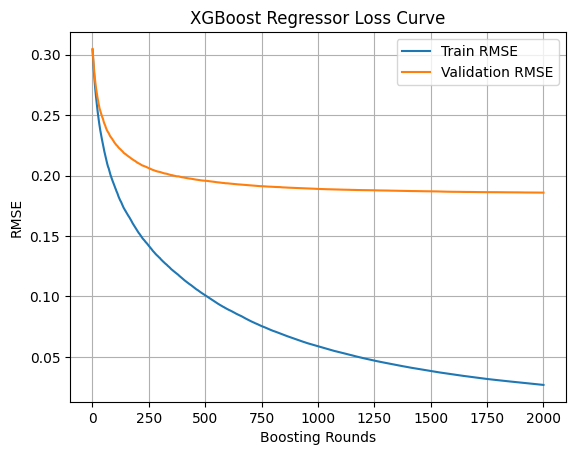

In [159]:
import matplotlib.pyplot as plt

results = xgb_model.evals_result()
epochs = range(1, len(results['validation_0']['rmse']) + 1)

fig, ax = plt.subplots()
ax.plot(epochs, results['validation_0']['rmse'], label='Train RMSE')
ax.plot(epochs, results['validation_1']['rmse'], label='Validation RMSE')
ax.legend()

plt.xlabel('Boosting Rounds')
plt.ylabel('RMSE')
plt.title('XGBoost Regressor Loss Curve')
plt.grid(True)
plt.show()

In [160]:

from xgboost import XGBRegressor


xgb_model_improved = XGBRegressor(
    n_estimators=2000,
    learning_rate=0.02, 
    max_depth=3,
    subsample=0.7,
    colsample_bytree=0.7,  
    min_child_weight=8, 
    reg_lambda=5.0, 
    reg_alpha=1.0,
    gamma=0.1, 
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=50,
    tree_method="hist"
)


eval_set = [(X_train, y_train), (X_val, y_val)]

xgb_model_improved.fit(
    X_train, y_train, 
    eval_set=eval_set, 
    verbose=False
)

y_pred_xgb_improved = xgb_model_improved.predict(X_test)
print(f"Improved XGBoost Test Set - R Squared: {r2_score(y_test, y_pred_xgb_improved):.3f}")
print(f"Improved XGBoost Test Set - RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_xgb_improved)):.3f}")


y_train_pred_xgb_improved = xgb_model_improved.predict(X_train)
print(f"\nTrain R²: {r2_score(y_train, y_train_pred_xgb_improved):.4f}")
print(f"Test R²:  {r2_score(y_test, y_pred_xgb_improved):.4f}")
print(f"Overfitting gap: {r2_score(y_train, y_train_pred_xgb_improved) - r2_score(y_test, y_pred_xgb_improved):.4f}")


Improved XGBoost Test Set - R Squared: 0.530
Improved XGBoost Test Set - RMSE: 0.212

Train R²: 0.7354
Test R²:  0.5300
Overfitting gap: 0.2054


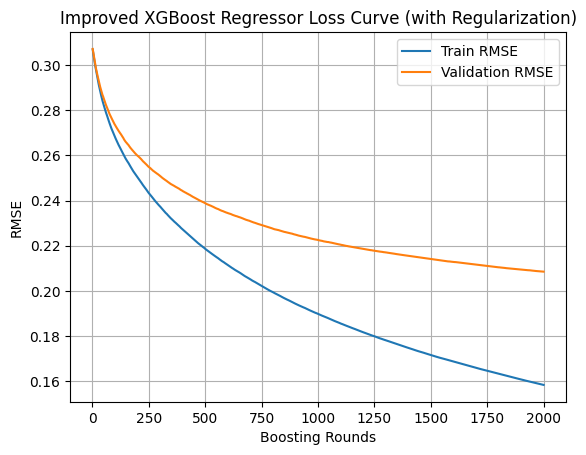

In [161]:
import matplotlib.pyplot as plt

results_improved = xgb_model_improved.evals_result()
epochs_improved = range(1, len(results_improved['validation_0']['rmse']) + 1)

fig, ax = plt.subplots()
ax.plot(epochs_improved, results_improved['validation_0']['rmse'], label='Train RMSE')
ax.plot(epochs_improved, results_improved['validation_1']['rmse'], label='Validation RMSE')
ax.legend()

plt.xlabel('Boosting Rounds')
plt.ylabel('RMSE')
plt.title('Improved XGBoost Regressor Loss Curve (with Regularization)')
plt.grid(True)
plt.show()


LIGHTGBM

In [162]:
import lightgbm as lgb

lgb_model_improved = lgb.LGBMRegressor(
    n_estimators=2000,
    learning_rate=0.02, 
    num_leaves=15, 
    max_depth=3,  
    min_child_samples=20, 
    subsample=0.7,  
    colsample_bytree=0.7,  
    reg_alpha=1.0,
    reg_lambda=5.0,  
    min_split_gain=0.1,  
    random_state=42
)


eval_set = [(X_train, y_train), (X_val, y_val)]

lgb_model_improved.fit(X_train, y_train, eval_set=eval_set, eval_metric="rmse", callbacks=[lgb.early_stopping(stopping_rounds=50)])


y_pred_lgb_improved = lgb_model_improved.predict(X_test)
print(f"Improved LightGBM Test R²: {r2_score(y_test, y_pred_lgb_improved):.4f}")
print(f"Improved LightGBM Test RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_lgb_improved)):.4f}")


y_train_pred_improved = lgb_model_improved.predict(X_train)
print(f"\nTrain R²: {r2_score(y_train, y_train_pred_improved):.4f}")
print(f"Test R²:  {r2_score(y_test, y_pred_lgb_improved):.4f}")
print(f"Overfitting gap: {r2_score(y_train, y_train_pred_improved) - r2_score(y_test, y_pred_lgb_improved):.4f}")


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.024328 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 356038
[LightGBM] [Info] Number of data points in the train set: 9685, number of used features: 1536
[LightGBM] [Info] Start training from score 0.347778
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 50 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

In [163]:
y_train_pred = xgb_model.predict(X_train)

print("Train R²:", r2_score(y_train, y_train_pred))
print("Test  R²:", r2_score(y_test, y_pred_xgb))

Train R²: 0.9924238324165344
Test  R²: 0.6315891742706299


In [164]:
import lightgbm as lgb

lgb_model = lgb.LGBMRegressor(n_estimators=2000, learning_rate=0.1, random_state=42)

eval_set = [(X_train, y_train), (X_val, y_val)]                                                                                                                             

lgb_model.fit(X_train, y_train, eval_set=eval_set, eval_metric="rmse", callbacks=[lgb.early_stopping(stopping_rounds=50)])

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.023373 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 356038
[LightGBM] [Info] Number of data points in the train set: 9685, number of used features: 1536
[LightGBM] [Info] Start training from score 0.347778
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[1333]	training's rmse: 0.0110802	training's l2: 0.00012277	valid_1's rmse: 0.187791	valid_1's l2: 0.0352654


LGBMRegressor(n_estimators=2000, random_state=42)

In [165]:
from sklearn.metrics import r2_score, mean_squared_error

y_pred_lgb = lgb_model.predict(X_test)
print(f"Test Set - R Squared: {r2_score(y_test, y_pred_lgb):.3f}")
print(f"Test Set - RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_lgb)):.3f}")

Test Set - R Squared: 0.627
Test Set - RMSE: 0.189


In [166]:
y_train_pred_lgb = lgb_model.predict(X_train)

print("Train R²:", r2_score(y_train, y_train_pred_lgb))
print("Test  R²:", r2_score(y_test, y_pred_lgb))

Train R²: 0.9987034840390638
Test  R²: 0.6269432671948925


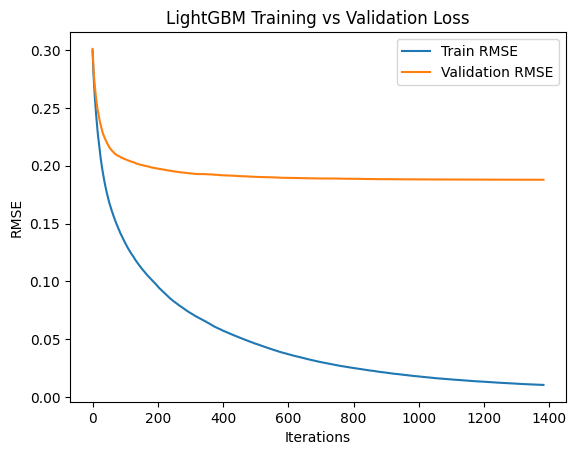

In [167]:
import matplotlib.pyplot as plt

results_lgb = lgb_model.evals_result_

train_rmse = results_lgb['training']['rmse']
val_rmse = results_lgb['valid_1']['rmse']

plt.plot(train_rmse, label="Train RMSE")
plt.plot(val_rmse, label="Validation RMSE")
plt.xlabel("Iterations")
plt.ylabel("RMSE")
plt.title("LightGBM Training vs Validation Loss")
plt.legend()
plt.show()

In [168]:
print("\n" + "="*50)
print("=== LightGBM Validation Set Results ===")
print("="*50)

y_val_pred_lgb = lgb_model.predict(X_val)

y_val_true_lgb = np.ravel(y_val)
y_val_pred_lgb = np.ravel(y_val_pred_lgb)

r2_val_lgb  = r2_score(y_val_true_lgb, y_val_pred_lgb)
mae_val_lgb = mean_absolute_error(y_val_true_lgb, y_val_pred_lgb)
rmse_val_lgb = np.sqrt(mean_squared_error(y_val_true_lgb, y_val_pred_lgb))

print(f"Samples: {len(y_val_true_lgb)}")
print(f"R²   : {r2_val_lgb:.4f}")
print(f"MAE  : {mae_val_lgb:.4f}")
print(f"RMSE : {rmse_val_lgb:.4f}")

print("\n" + "="*50)
print("LightGBM: Train/Val/Test Comparison")
print("="*50)

y_train_pred_lgb = lgb_model.predict(X_train)
r2_train_lgb = r2_score(y_train, y_train_pred_lgb)
mae_train_lgb = mean_absolute_error(y_train, y_train_pred_lgb)
rmse_train_lgb = np.sqrt(mean_squared_error(y_train, y_train_pred_lgb))

r2_test_lgb = r2_score(y_test, y_pred_lgb)
mae_test_lgb = mean_absolute_error(y_test, y_pred_lgb)
rmse_test_lgb = np.sqrt(mean_squared_error(y_test, y_pred_lgb))

comparison_df_lgb = pd.DataFrame({
    "Set": ["Train", "Validation", "Test"],
    "Samples": [len(y_train), len(y_val_true_lgb), len(y_test)],
    "R²": [r2_train_lgb, r2_val_lgb, r2_test_lgb],
    "MAE": [mae_train_lgb, mae_val_lgb, mae_test_lgb],
    "RMSE": [rmse_train_lgb, rmse_val_lgb, rmse_test_lgb]
})
print(comparison_df_lgb.to_string(index=False))



=== LightGBM Validation Set Results ===
Samples: 2768
R²   : 0.6273
MAE  : 0.1330
RMSE : 0.1878

LightGBM: Train/Val/Test Comparison
       Set  Samples       R²      MAE     RMSE
     Train     9685 0.998703 0.005998 0.011080
Validation     2768 0.627308 0.133009 0.187791
      Test     1384 0.626943 0.134807 0.188737


=== XGBoost Test Set Results ===
Samples: 1384
R²   : 0.6316
MAE  : 0.1342
RMSE : 0.1876
Predictions saved to `models/xgb_predictions.csv`
Model saved to `models/xgb_res3.pkl`


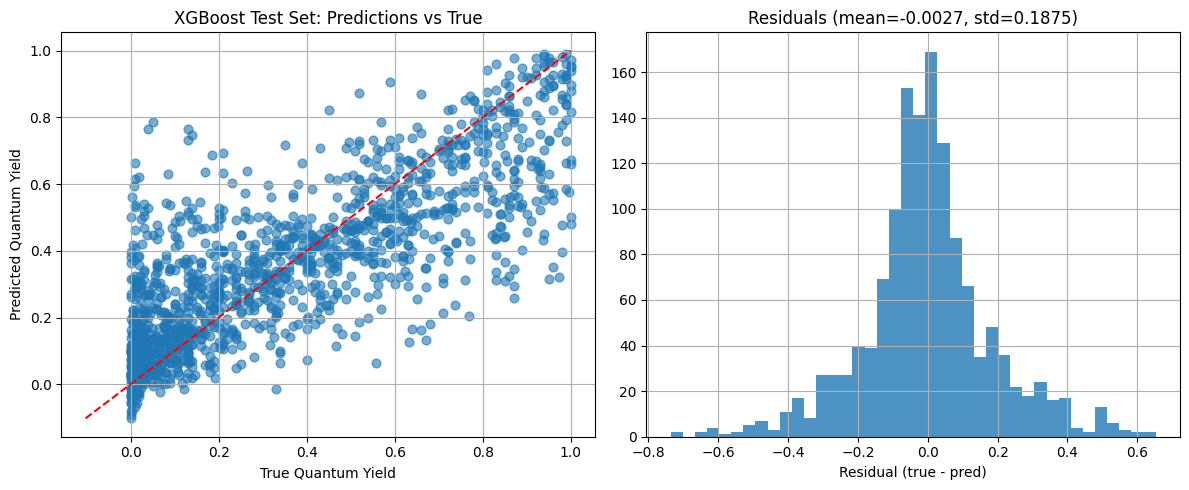

In [169]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import joblib
import os


y_pred = xgb_model.predict(X_test)


y_true = np.ravel(y_test)
y_pred = np.ravel(y_pred)


r2  = r2_score(y_true, y_pred)
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

print("=== XGBoost Test Set Results ===")
print(f"Samples: {len(y_true)}")
print(f"R²   : {r2:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")


os.makedirs("models", exist_ok=True)
pred_df = pd.DataFrame({"y_true": y_true, "y_pred": y_pred})
pred_df.to_csv("models/xgb_predictions.csv", index=False)
print("Predictions saved to `models/xgb_predictions.csv`")


joblib.dump(xgb_model, "models/xgb_res3.pkl")
print("Model saved to `models/xgb_res3.pkl`")


plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.scatter(y_true, y_pred, alpha=0.6, s=40)
mn, mx = min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())
plt.plot([mn, mx], [mn, mx], 'r--', lw=1.5)
plt.xlabel("True Quantum Yield")
plt.ylabel("Predicted Quantum Yield")
plt.title("XGBoost Test Set: Predictions vs True")
plt.grid(True)

plt.subplot(1,2,2)
residuals = y_true - y_pred
plt.hist(residuals, bins=40, alpha=0.8)
plt.xlabel("Residual (true - pred)")
plt.title(f"Residuals (mean={residuals.mean():.4f}, std={residuals.std():.4f})")
plt.grid(True)

plt.tight_layout()
plt.show()

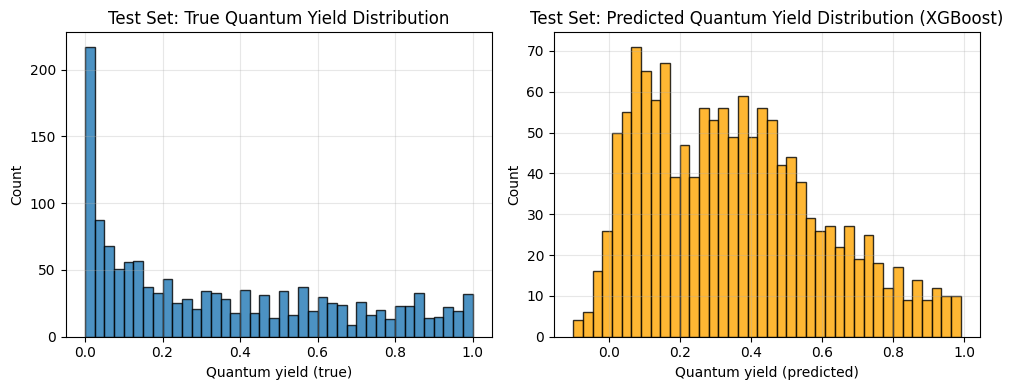

In [170]:

plt.figure(figsize=(10,4))


plt.subplot(1,2,1)
plt.hist(y_true, bins=40, alpha=0.8, edgecolor="black")
plt.xlabel("Quantum yield (true)")
plt.ylabel("Count")
plt.title("Test Set: True Quantum Yield Distribution")
plt.grid(True, alpha=0.3)


plt.subplot(1,2,2)
plt.hist(y_pred, bins=40, alpha=0.8, edgecolor="black", color="orange")
plt.xlabel("Quantum yield (predicted)")
plt.ylabel("Count")
plt.title("Test Set: Predicted Quantum Yield Distribution (XGBoost)")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


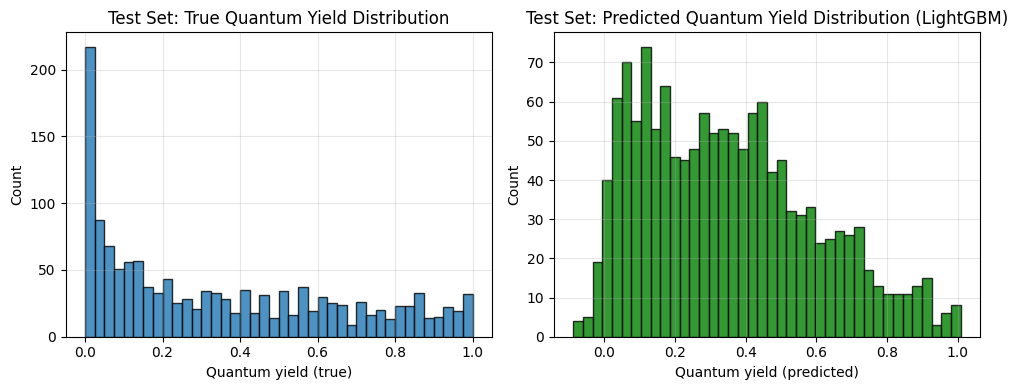

In [171]:
# Histograms of quantum yield after modeling (test set) - LightGBM
plt.figure(figsize=(10,4))

# True distribution on test set
plt.subplot(1,2,1)
plt.hist(y_test, bins=40, alpha=0.8, edgecolor="black")
plt.xlabel("Quantum yield (true)")
plt.ylabel("Count")
plt.title("Test Set: True Quantum Yield Distribution")
plt.grid(True, alpha=0.3)

# Predicted distribution on test set (LightGBM)
plt.subplot(1,2,2)
plt.hist(y_pred_lgb, bins=40, alpha=0.8, edgecolor="black", color="green")
plt.xlabel("Quantum yield (predicted)")
plt.ylabel("Count")
plt.title("Test Set: Predicted Quantum Yield Distribution (LightGBM)")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


=== XGBoost Validation Set Results ===
Samples: 2768
R²   : 0.6349
MAE  : 0.1320
RMSE : 0.1859


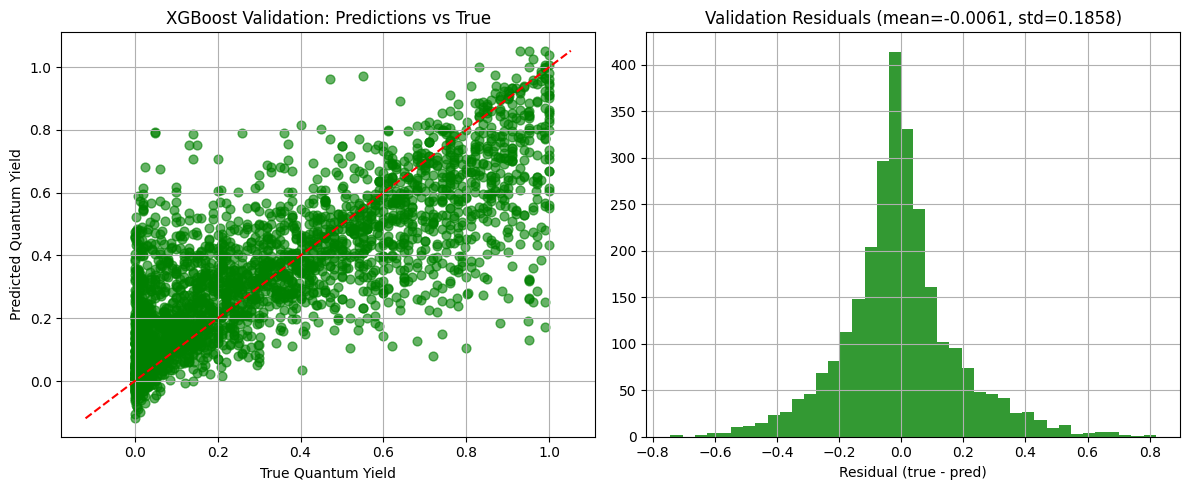


XGBoost: Train/Val/Test Comparison
       Set  Samples       R²      MAE     RMSE
     Train     9685 0.992424 0.018133 0.026784
Validation     2768 0.634872 0.132040 0.185875
      Test     1384 0.631589 0.134153 0.187558


In [172]:

print("\n" + "="*50)
print("=== XGBoost Validation Set Results ===")
print("="*50)

y_val_pred = xgb_model.predict(X_val)


y_val_true = np.ravel(y_val)
y_val_pred = np.ravel(y_val_pred)


r2_val  = r2_score(y_val_true, y_val_pred)
mae_val = mean_absolute_error(y_val_true, y_val_pred)
rmse_val = np.sqrt(mean_squared_error(y_val_true, y_val_pred))

print(f"Samples: {len(y_val_true)}")
print(f"R²   : {r2_val:.4f}")
print(f"MAE  : {mae_val:.4f}")
print(f"RMSE : {rmse_val:.4f}")


plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_val_true, y_val_pred, alpha=0.6, s=40, color='green')
mn, mx = min(y_val_true.min(), y_val_pred.min()), max(y_val_true.max(), y_val_pred.max())
plt.plot([mn, mx], [mn, mx], 'r--', lw=1.5)
plt.xlabel("True Quantum Yield")
plt.ylabel("Predicted Quantum Yield")
plt.title("XGBoost Validation: Predictions vs True")
plt.grid(True)

plt.subplot(1, 2, 2)
residuals_val = y_val_true - y_val_pred
plt.hist(residuals_val, bins=40, alpha=0.8, color='green')
plt.xlabel("Residual (true - pred)")
plt.title(f"Validation Residuals (mean={residuals_val.mean():.4f}, std={residuals_val.std():.4f})")
plt.grid(True)

plt.tight_layout()
plt.show()


print("\n" + "="*50)
print("XGBoost: Train/Val/Test Comparison")
print("="*50)


y_train_pred = xgb_model.predict(X_train)
r2_train = r2_score(y_train, y_train_pred)
mae_train = mean_absolute_error(y_train, y_train_pred)
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))

comparison_df = pd.DataFrame({
    "Set": ["Train", "Validation", "Test"],
    "Samples": [len(y_train), len(y_val_true), len(y_true)],
    "R²": [r2_train, r2_val, r2],
    "MAE": [mae_train, mae_val, mae],
    "RMSE": [rmse_train, rmse_val, rmse]
})
print(comparison_df.to_string(index=False))


COMPREHENSIVE MODEL COMPARISON

--------------------------------------------------------------------------------
ALL MODELS: COMPREHENSIVE METRICS COMPARISON
--------------------------------------------------------------------------------
              Model  Train R²   Val R²  Test R²  Train RMSE  Val RMSE  Test RMSE  Train MAE  Val MAE  Test MAE  Overfitting Gap
 XGBoost (Original)  0.992424 0.634872 0.631589    0.026784  0.185875   0.187558   0.018133 0.132040  0.134153         0.360835
 XGBoost (Improved)  0.735392 0.540593 0.529970    0.158292  0.208496   0.211851   0.121764 0.160284  0.163977         0.205422
LightGBM (Original)  0.998703 0.627308 0.626943    0.011080  0.187791   0.188737   0.005998 0.133009  0.134807         0.371760
LightGBM (Improved)  0.702451 0.519641 0.511525    0.167856  0.213198   0.215968   0.130427 0.165403  0.168609         0.190926

--------------------------------------------------------------------------------
TEST SET PERFORMANCE RANKING (Best to 

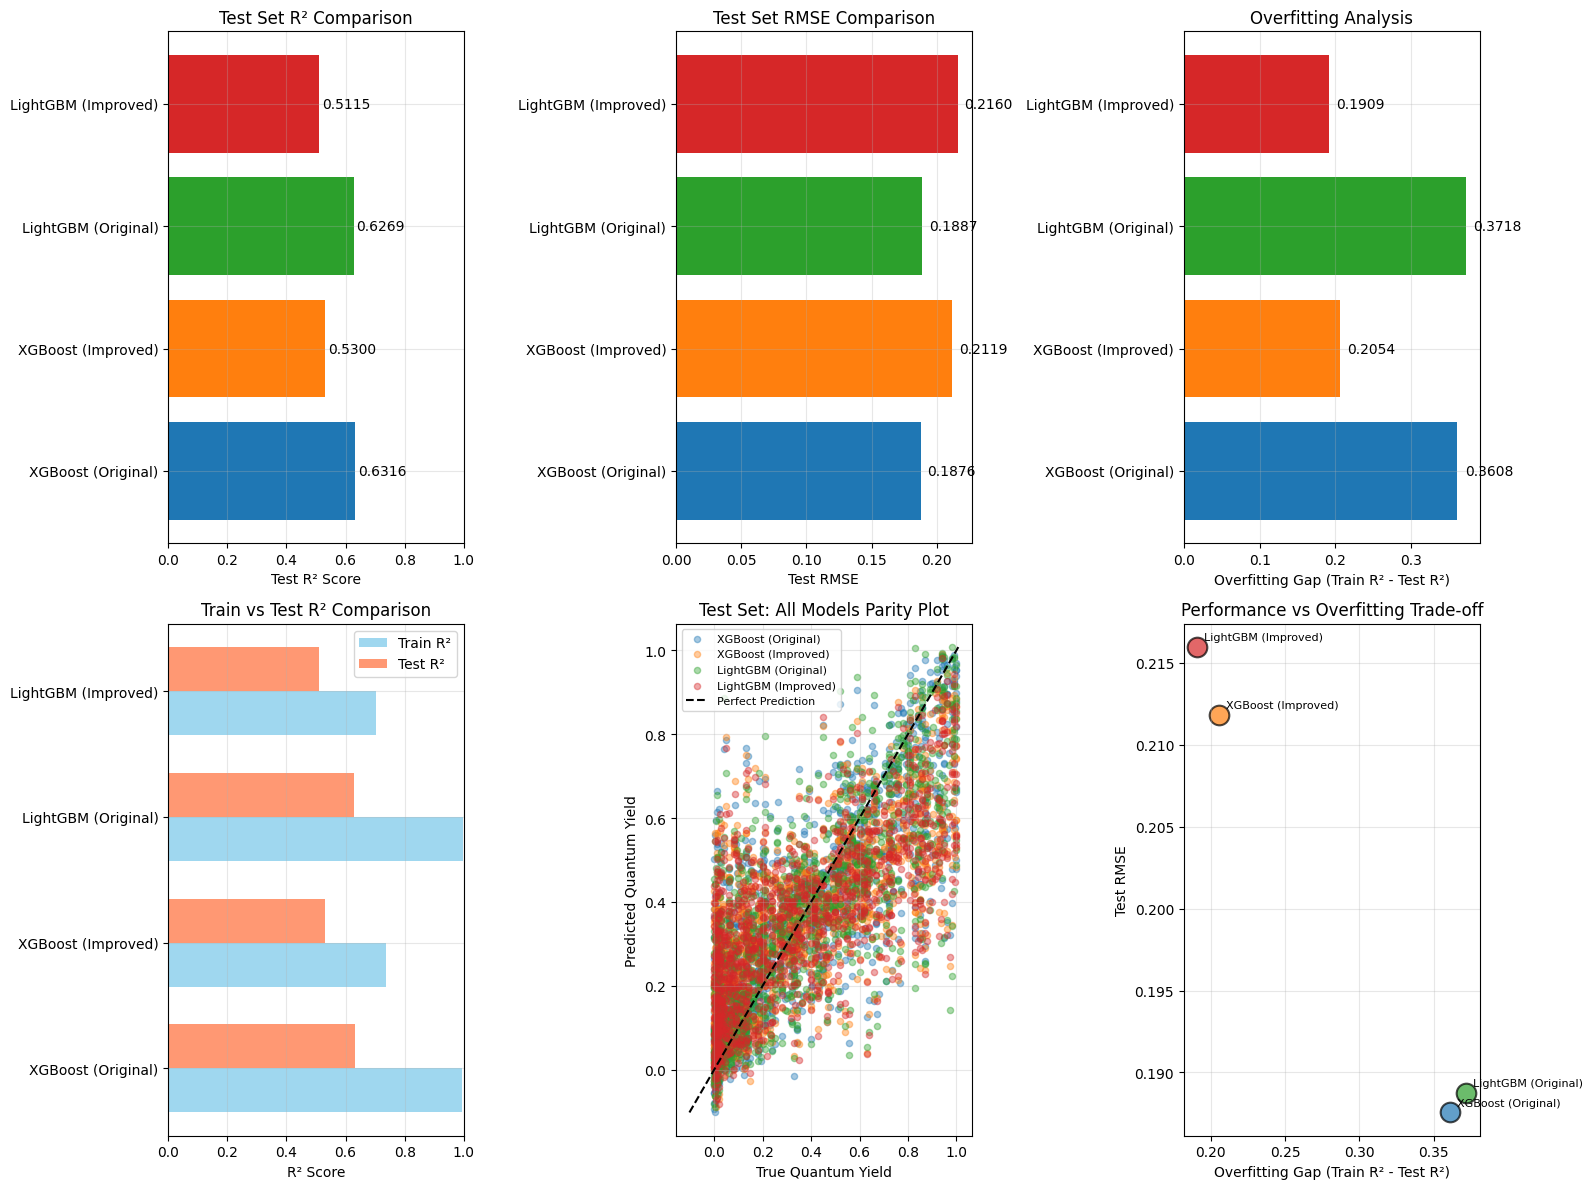


FINAL SUMMARY & RECOMMENDATIONS

🏆 Best Test Performance: XGBoost (Original)
   Test R²: 0.6316, Test RMSE: 0.1876

📊 Least Overfitting: LightGBM (Improved)
   Overfitting Gap: 0.1909

💡 Recommendation:
   For best predictions: Use XGBoost (Original) (Test R²: 0.6316)
   For more reliable/generalizable model: Use LightGBM (Improved) (Gap: 0.1909)



In [173]:
# ============================================================================
# COMPREHENSIVE MODEL COMPARISON: All 4 Models
# ============================================================================
# Compare: xgb_model (original), xgb_model_improved, lgb_model (original), lgb_model_improved

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

print("\n" + "="*80)
print("COMPREHENSIVE MODEL COMPARISON")
print("="*80)

# Get predictions for all models on all sets
models = {
    'XGBoost (Original)': {
        'model': xgb_model,
        'train_pred': xgb_model.predict(X_train),
        'val_pred': xgb_model.predict(X_val),
        'test_pred': xgb_model.predict(X_test)
    },
    'XGBoost (Improved)': {
        'model': xgb_model_improved,
        'train_pred': xgb_model_improved.predict(X_train),
        'val_pred': xgb_model_improved.predict(X_val),
        'test_pred': y_pred_xgb_improved
    },
    'LightGBM (Original)': {
        'model': lgb_model,
        'train_pred': lgb_model.predict(X_train),
        'val_pred': lgb_model.predict(X_val),
        'test_pred': y_pred_lgb
    },
    'LightGBM (Improved)': {
        'model': lgb_model_improved,
        'train_pred': lgb_model_improved.predict(X_train),
        'val_pred': lgb_model_improved.predict(X_val),
        'test_pred': y_pred_lgb_improved
    }
}

# Calculate metrics for all models
results = []
for model_name, preds in models.items():
    # Train metrics
    r2_train = r2_score(y_train, preds['train_pred'])
    mae_train = mean_absolute_error(y_train, preds['train_pred'])
    rmse_train = np.sqrt(mean_squared_error(y_train, preds['train_pred']))
    
    # Validation metrics
    r2_val = r2_score(y_val, preds['val_pred'])
    mae_val = mean_absolute_error(y_val, preds['val_pred'])
    rmse_val = np.sqrt(mean_squared_error(y_val, preds['val_pred']))
    
    # Test metrics
    r2_test = r2_score(y_test, preds['test_pred'])
    mae_test = mean_absolute_error(y_test, preds['test_pred'])
    rmse_test = np.sqrt(mean_squared_error(y_test, preds['test_pred']))
    
    # Overfitting gap
    overfitting_gap = r2_train - r2_test
    
    results.append({
        'Model': model_name,
        'Train R²': r2_train,
        'Val R²': r2_val,
        'Test R²': r2_test,
        'Train RMSE': rmse_train,
        'Val RMSE': rmse_val,
        'Test RMSE': rmse_test,
        'Train MAE': mae_train,
        'Val MAE': mae_val,
        'Test MAE': mae_test,
        'Overfitting Gap': overfitting_gap
    })

# Create comprehensive comparison DataFrame
comparison_df_all = pd.DataFrame(results)

print("\n" + "-"*80)
print("ALL MODELS: COMPREHENSIVE METRICS COMPARISON")
print("-"*80)
print(comparison_df_all.to_string(index=False))

# Summary: Test Set Performance Ranking
print("\n" + "-"*80)
print("TEST SET PERFORMANCE RANKING (Best to Worst)")
print("-"*80)
test_ranking = comparison_df_all[['Model', 'Test R²', 'Test RMSE', 'Test MAE', 'Overfitting Gap']].sort_values('Test R²', ascending=False)
print(test_ranking.to_string(index=False))

# Summary: Overfitting Analysis
print("\n" + "-"*80)
print("OVERFITTING ANALYSIS (Train R² - Test R²)")
print("-"*80)
overfitting_analysis = comparison_df_all[['Model', 'Train R²', 'Test R²', 'Overfitting Gap']].sort_values('Overfitting Gap', ascending=True)
print(overfitting_analysis.to_string(index=False))

# Visualizations
fig = plt.figure(figsize=(16, 12))

# 1. Test R² Comparison
ax1 = plt.subplot(2, 3, 1)
models_list = comparison_df_all['Model'].values
test_r2 = comparison_df_all['Test R²'].values
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
bars = ax1.barh(models_list, test_r2, color=colors)
ax1.set_xlabel('Test R² Score')
ax1.set_title('Test Set R² Comparison')
ax1.set_xlim([0, 1])
ax1.grid(True, alpha=0.3)
for i, (bar, val) in enumerate(zip(bars, test_r2)):
    ax1.text(val + 0.01, i, f'{val:.4f}', va='center')

# 2. Test RMSE Comparison
ax2 = plt.subplot(2, 3, 2)
test_rmse = comparison_df_all['Test RMSE'].values
bars = ax2.barh(models_list, test_rmse, color=colors)
ax2.set_xlabel('Test RMSE')
ax2.set_title('Test Set RMSE Comparison')
ax2.grid(True, alpha=0.3)
for i, (bar, val) in enumerate(zip(bars, test_rmse)):
    ax2.text(val + 0.005, i, f'{val:.4f}', va='center')

# 3. Overfitting Gap Comparison
ax3 = plt.subplot(2, 3, 3)
overfitting_gaps = comparison_df_all['Overfitting Gap'].values
bars = ax3.barh(models_list, overfitting_gaps, color=colors)
ax3.set_xlabel('Overfitting Gap (Train R² - Test R²)')
ax3.set_title('Overfitting Analysis')
ax3.grid(True, alpha=0.3)
for i, (bar, val) in enumerate(zip(bars, overfitting_gaps)):
    ax3.text(val + 0.01, i, f'{val:.4f}', va='center')

# 4. Train vs Test R² Comparison
ax4 = plt.subplot(2, 3, 4)
train_r2 = comparison_df_all['Train R²'].values
x_pos = np.arange(len(models_list))
width = 0.35
ax4.barh(x_pos - width/2, train_r2, width, label='Train R²', color='skyblue', alpha=0.8)
ax4.barh(x_pos + width/2, test_r2, width, label='Test R²', color='coral', alpha=0.8)
ax4.set_yticks(x_pos)
ax4.set_yticklabels(models_list)
ax4.set_xlabel('R² Score')
ax4.set_title('Train vs Test R² Comparison')
ax4.legend()
ax4.set_xlim([0, 1])
ax4.grid(True, alpha=0.3)

# 5. Test Set Predictions vs True (Parity Plots) - All models
ax5 = plt.subplot(2, 3, 5)
for i, (model_name, preds) in enumerate(models.items()):
    test_pred = preds['test_pred']
    ax5.scatter(y_test, test_pred, alpha=0.4, s=20, label=model_name, color=colors[i])
mn, mx = min(y_test.min(), min([p['test_pred'].min() for p in models.values()])), \
         max(y_test.max(), max([p['test_pred'].max() for p in models.values()]))
ax5.plot([mn, mx], [mn, mx], 'k--', lw=1.5, label='Perfect Prediction')
ax5.set_xlabel('True Quantum Yield')
ax5.set_ylabel('Predicted Quantum Yield')
ax5.set_title('Test Set: All Models Parity Plot')
ax5.legend(fontsize=8)
ax5.grid(True, alpha=0.3)

# 6. Test RMSE vs Overfitting Gap Trade-off
ax6 = plt.subplot(2, 3, 6)
for i, model_name in enumerate(models_list):
    ax6.scatter(overfitting_gaps[i], test_rmse[i], s=200, color=colors[i], 
                label=model_name, alpha=0.7, edgecolors='black', linewidth=1.5)
    ax6.annotate(model_name, (overfitting_gaps[i], test_rmse[i]), 
                xytext=(5, 5), textcoords='offset points', fontsize=8)
ax6.set_xlabel('Overfitting Gap (Train R² - Test R²)')
ax6.set_ylabel('Test RMSE')
ax6.set_title('Performance vs Overfitting Trade-off')
ax6.grid(True, alpha=0.3)
# Ideal: lower overfitting gap AND lower RMSE (bottom-left is best)

plt.tight_layout()
plt.show()

# Final Summary
print("\n" + "="*80)
print("FINAL SUMMARY & RECOMMENDATIONS")
print("="*80)
best_test_r2_idx = comparison_df_all['Test R²'].idxmax()
best_model = comparison_df_all.loc[best_test_r2_idx, 'Model']
best_test_r2 = comparison_df_all.loc[best_test_r2_idx, 'Test R²']
best_test_rmse = comparison_df_all.loc[best_test_r2_idx, 'Test RMSE']

lowest_overfitting_idx = comparison_df_all['Overfitting Gap'].idxmin()
least_overfit_model = comparison_df_all.loc[lowest_overfitting_idx, 'Model']
least_overfit_gap = comparison_df_all.loc[lowest_overfitting_idx, 'Overfitting Gap']

print(f"\n🏆 Best Test Performance: {best_model}")
print(f"   Test R²: {best_test_r2:.4f}, Test RMSE: {best_test_rmse:.4f}")

print(f"\n📊 Least Overfitting: {least_overfit_model}")
print(f"   Overfitting Gap: {least_overfit_gap:.4f}")

print(f"\n💡 Recommendation:")
if best_model == least_overfit_model:
    print(f"   {best_model} is the best overall choice (best performance + least overfitting)")
else:
    print(f"   For best predictions: Use {best_model} (Test R²: {best_test_r2:.4f})")
    print(f"   For more reliable/generalizable model: Use {least_overfit_model} (Gap: {least_overfit_gap:.4f})")
    
print("\n" + "="*80)


In [174]:
print(str(round(4.5)))

4


In [175]:
# ============================================================================
# MULTI-LAYER PERCEPTRON (MLP) REGRESSOR
# ============================================================================

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

class MLPRegressor(nn.Module):
    def __init__(self, input_dim=1536, hidden_dims=[512, 256, 128], dropout=0.3):
        super().__init__()
        
        layers = []
        prev_dim = input_dim
        
        for hidden_dim in hidden_dims:
            layers.extend([
                nn.Linear(prev_dim, hidden_dim),
                nn.BatchNorm1d(hidden_dim),
                nn.ReLU(),
                nn.Dropout(dropout),
            ])
            prev_dim = hidden_dim
        
        layers.append(nn.Linear(prev_dim, 1))
        
        self.mlp = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.mlp(x)

# Initialize model
input_dim = X_train.shape[1]
mlp_model = MLPRegressor(input_dim=input_dim, hidden_dims=[512, 256, 128], dropout=0.3)

print(f"MLP Model Architecture:")
print(mlp_model)
print(f"\nTotal parameters: {sum(p.numel() for p in mlp_model.parameters()):,}")

MLP Model Architecture:
MLPRegressor(
  (mlp): Sequential(
    (0): Linear(in_features=1536, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=256, out_features=128, bias=True)
    (9): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=128, out_features=1, bias=True)
  )
)

Total parameters: 953,089


In [176]:
# ============================================================================
# TRAIN MLP
# ============================================================================

# Prepare data loaders
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32).unsqueeze(1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

# Training setup
device = torch.device("cpu")
mlp_model = mlp_model.to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(mlp_model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)

# Training loop
num_epochs = 200
best_val_loss = float('inf')
train_losses = []
val_losses = []
patience = 30
patience_counter = 0

for epoch in range(num_epochs):
    # Training
    mlp_model.train()
    train_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        
        optimizer.zero_grad()
        outputs = mlp_model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    
    train_loss /= len(train_loader)
    train_losses.append(train_loss)
    
    # Validation
    mlp_model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = mlp_model(X_batch)
            loss = criterion(outputs, y_batch)
            val_loss += loss.item()
    
    val_loss /= len(val_loader)
    val_losses.append(val_loss)
    
    scheduler.step(val_loss)
    
    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = mlp_model.state_dict().copy()
        patience_counter = 0
    else:
        patience_counter += 1
    
    if patience_counter >= patience:
        print(f"Early stopping at epoch {epoch+1}")
        break
    
    if (epoch + 1) % 20 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}] Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

# Load best model
mlp_model.load_state_dict(best_model_state)
print(f"\nBest validation loss: {best_val_loss:.4f}")

Epoch [20/200] Train Loss: 0.0435, Val Loss: 0.0528
Epoch [40/200] Train Loss: 0.0397, Val Loss: 0.0479
Epoch [60/200] Train Loss: 0.0369, Val Loss: 0.0456
Epoch [80/200] Train Loss: 0.0272, Val Loss: 0.0411
Epoch [100/200] Train Loss: 0.0203, Val Loss: 0.0382
Epoch [120/200] Train Loss: 0.0168, Val Loss: 0.0371
Epoch [140/200] Train Loss: 0.0137, Val Loss: 0.0363
Epoch [160/200] Train Loss: 0.0131, Val Loss: 0.0365
Early stopping at epoch 175

Best validation loss: 0.0359


MLP RESULTS
Train R²: 0.9551
Val R²:   0.6244
Test R²:  0.6262
Test RMSE: 0.1889
Test MAE:  0.1291
Overfitting Gap: 0.3290


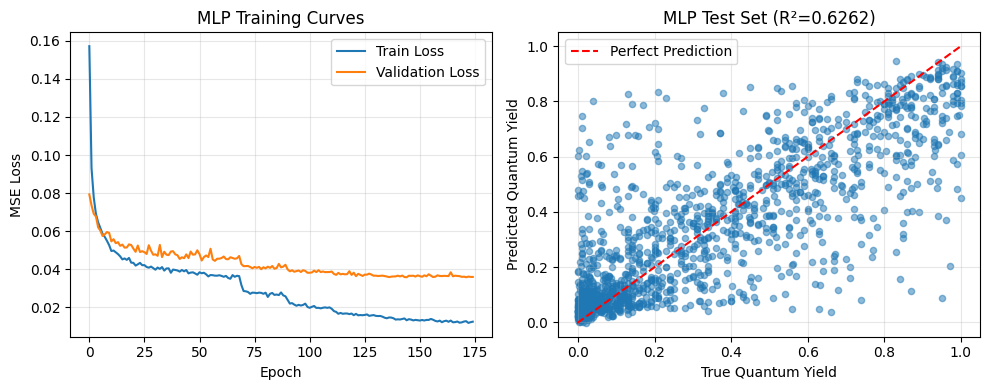

In [177]:
# ============================================================================
# EVALUATE MLP
# ============================================================================

# Plot training curves
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('MLP Training Curves')
plt.legend()
plt.grid(True, alpha=0.3)

# Evaluate on all sets
mlp_model.eval()
with torch.no_grad():
    y_train_pred_mlp = mlp_model(X_train_tensor.to(device)).cpu().numpy().squeeze()
    y_val_pred_mlp = mlp_model(X_val_tensor.to(device)).cpu().numpy().squeeze()
    y_pred_mlp = mlp_model(X_test_tensor.to(device)).cpu().numpy().squeeze()

# Calculate metrics
train_r2_mlp = r2_score(y_train, y_train_pred_mlp)
val_r2_mlp = r2_score(y_val, y_val_pred_mlp)
test_r2_mlp = r2_score(y_test, y_pred_mlp)
test_rmse_mlp = np.sqrt(mean_squared_error(y_test, y_pred_mlp))
test_mae_mlp = mean_absolute_error(y_test, y_pred_mlp)

print("="*50)
print("MLP RESULTS")
print("="*50)
print(f"Train R²: {train_r2_mlp:.4f}")
print(f"Val R²:   {val_r2_mlp:.4f}")
print(f"Test R²:  {test_r2_mlp:.4f}")
print(f"Test RMSE: {test_rmse_mlp:.4f}")
print(f"Test MAE:  {test_mae_mlp:.4f}")
print(f"Overfitting Gap: {train_r2_mlp - test_r2_mlp:.4f}")

# Parity plot
plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_mlp, alpha=0.5, s=20)
mn, mx = min(y_test.min(), y_pred_mlp.min()), max(y_test.max(), y_pred_mlp.max())
plt.plot([mn, mx], [mn, mx], 'r--', lw=1.5, label='Perfect Prediction')
plt.xlabel('True Quantum Yield')
plt.ylabel('Predicted Quantum Yield')
plt.title(f'MLP Test Set (R²={test_r2_mlp:.4f})')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

MODEL COMPARISON (Including MLP)
   Model  Train R²   Val R²  Test R²  Test RMSE  Test MAE  Overfitting Gap
 XGBoost  0.992424 0.634872 0.631589   0.187558  0.134153         0.360835
LightGBM  0.998703 0.627308 0.626943   0.188737  0.134807         0.371760
     MLP  0.955129 0.624389 0.626150   0.188937  0.129134         0.328978


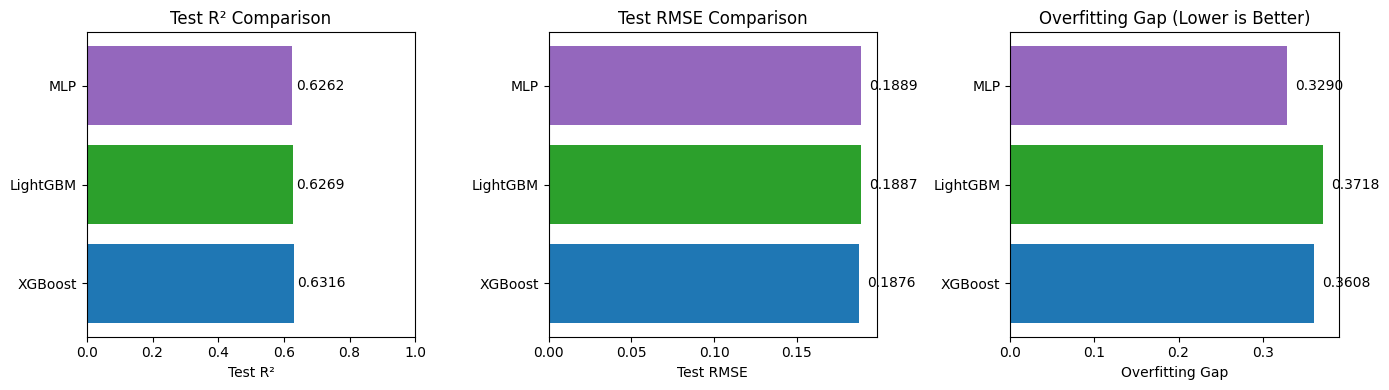


🏆 Best Model: XGBoost (Test R²: 0.6316)


In [178]:
# ============================================================================
# COMPARE MLP WITH OTHER MODELS
# ============================================================================

print("="*70)
print("MODEL COMPARISON (Including MLP)")
print("="*70)

# Create comparison dataframe
comparison_with_mlp = pd.DataFrame({
    'Model': ['XGBoost', 'LightGBM', 'MLP'],
    'Train R²': [
        r2_score(y_train, xgb_model.predict(X_train)),
        r2_score(y_train, lgb_model.predict(X_train)),
        train_r2_mlp
    ],
    'Val R²': [
        r2_score(y_val, xgb_model.predict(X_val)),
        r2_score(y_val, lgb_model.predict(X_val)),
        val_r2_mlp
    ],
    'Test R²': [
        r2_score(y_test, y_pred_xgb),
        r2_score(y_test, y_pred_lgb),
        test_r2_mlp
    ],
    'Test RMSE': [
        np.sqrt(mean_squared_error(y_test, y_pred_xgb)),
        np.sqrt(mean_squared_error(y_test, y_pred_lgb)),
        test_rmse_mlp
    ],
    'Test MAE': [
        mean_absolute_error(y_test, y_pred_xgb),
        mean_absolute_error(y_test, y_pred_lgb),
        test_mae_mlp
    ]
})

comparison_with_mlp['Overfitting Gap'] = comparison_with_mlp['Train R²'] - comparison_with_mlp['Test R²']

print(comparison_with_mlp.to_string(index=False))

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Test R² comparison
colors = ['#1f77b4', '#2ca02c', '#9467bd']
axes[0].barh(comparison_with_mlp['Model'], comparison_with_mlp['Test R²'], color=colors)
axes[0].set_xlabel('Test R²')
axes[0].set_title('Test R² Comparison')
axes[0].set_xlim([0, 1])
for i, v in enumerate(comparison_with_mlp['Test R²']):
    axes[0].text(v + 0.01, i, f'{v:.4f}', va='center')

# Test RMSE comparison  
axes[1].barh(comparison_with_mlp['Model'], comparison_with_mlp['Test RMSE'], color=colors)
axes[1].set_xlabel('Test RMSE')
axes[1].set_title('Test RMSE Comparison')
for i, v in enumerate(comparison_with_mlp['Test RMSE']):
    axes[1].text(v + 0.005, i, f'{v:.4f}', va='center')

# Overfitting gap comparison
axes[2].barh(comparison_with_mlp['Model'], comparison_with_mlp['Overfitting Gap'], color=colors)
axes[2].set_xlabel('Overfitting Gap')
axes[2].set_title('Overfitting Gap (Lower is Better)')
for i, v in enumerate(comparison_with_mlp['Overfitting Gap']):
    axes[2].text(v + 0.01, i, f'{v:.4f}', va='center')

plt.tight_layout()
plt.show()

# Best model recommendation
best_idx = comparison_with_mlp['Test R²'].idxmax()
print(f"\n🏆 Best Model: {comparison_with_mlp.loc[best_idx, 'Model']} (Test R²: {comparison_with_mlp.loc[best_idx, 'Test R²']:.4f})")